# Model Training

## Food Price Volatility & Market Risk Prediction

This notebook trains and evaluates machine learning models for classifying near-future food price volatility risk into Low, Medium, and High categories.

The data is split chronologically into training, validation, and final test periods to respect the time-dependent nature of the problem.

In [22]:
import pandas as pd
import numpy as np

print("Model training notebook initialized.")

Model training notebook initialized.


In [23]:
import pandas as pd
import numpy as np

years = [2022, 2023, 2024, 2025, 2026]

dfs = []

for year in years:
    df_year = pd.read_csv(
        f"../data/processed/cleaned_{year}.csv"
    )
    df_year["Arrival_Date"] = pd.to_datetime(df_year["Arrival_Date"])
    dfs.append(df_year)

df = pd.concat(dfs, ignore_index=True)

print("Combined raw modeling source:")
print("Shape:", df.shape)
print("Date range:", df["Arrival_Date"].min(), "to", df["Arrival_Date"].max())

Combined raw modeling source:
Shape: (2522952, 11)
Date range: 2022-01-01 00:00:00 to 2026-04-20 00:00:00


In [30]:
daily_df = (
    df.groupby(
        ["Commodity", "Market", "Arrival_Date"],
        as_index=False
    )
    .agg(
        Daily_Modal_Price=("Modal_Price", "median")
    )
)

print("Daily dataset shape:", daily_df.shape)

print("\nColumns:")
print(daily_df.columns.tolist())

print("\nMissing values:")
print(daily_df.isna().sum())

Daily dataset shape: (2433600, 4)

Columns:
['Commodity', 'Market', 'Arrival_Date', 'Daily_Modal_Price']

Missing values:
Commodity            0
Market               0
Arrival_Date         0
Daily_Modal_Price    0
dtype: int64


In [31]:
daily_df = daily_df.sort_values(
    ["Commodity", "Market", "Arrival_Date"]
).reset_index(drop=True)

for lag in [1, 3, 7]:
    daily_df[f"Lag_{lag}_Price"] = (
        daily_df
        .groupby(["Commodity", "Market"])["Daily_Modal_Price"]
        .shift(lag)
    )

print(
    daily_df[
        [
            "Commodity",
            "Market",
            "Arrival_Date",
            "Daily_Modal_Price",
            "Lag_1_Price",
            "Lag_3_Price",
            "Lag_7_Price"
        ]
    ].head(15)
)

print("\nMissing values:")
print(
    daily_df[
        ["Lag_1_Price", "Lag_3_Price", "Lag_7_Price"]
    ].isna().sum()
)

   Commodity Market Arrival_Date  Daily_Modal_Price  Lag_1_Price  Lag_3_Price  \
0      Onion  A lot   2022-05-24              280.0          NaN          NaN   
1      Onion  A lot   2022-05-25              280.0        280.0          NaN   
2      Onion  A lot   2022-05-26              200.0        280.0          NaN   
3      Onion  A lot   2022-05-27              245.0        200.0        280.0   
4      Onion  A lot   2022-05-28              245.0        245.0        280.0   
5      Onion  A lot   2022-05-29              220.0        245.0        200.0   
6      Onion  A lot   2022-05-30              270.0        220.0        245.0   
7      Onion  A lot   2022-05-31              200.0        270.0        245.0   
8      Onion  A lot   2022-06-01              245.0        200.0        220.0   
9      Onion  A lot   2022-06-02              401.0        245.0        270.0   
10     Onion  A lot   2022-06-03              150.0        401.0        200.0   
11     Onion  A lot   2022-0

In [26]:
daily_df["Price_Change_1D"] = (
    daily_df["Daily_Modal_Price"] / daily_df["Lag_1_Price"]
) - 1

daily_df["Price_Change_3D"] = (
    daily_df["Daily_Modal_Price"] / daily_df["Lag_3_Price"]
) - 1

daily_df["Price_Change_7D"] = (
    daily_df["Daily_Modal_Price"] / daily_df["Lag_7_Price"]
) - 1

print(
    daily_df[
        [
            "Commodity",
            "Market",
            "Arrival_Date",
            "Daily_Modal_Price",
            "Price_Change_1D",
            "Price_Change_3D",
            "Price_Change_7D"
        ]
    ].head(15)
)

print("\nMissing values:")
print(
    daily_df[
        [
            "Price_Change_1D",
            "Price_Change_3D",
            "Price_Change_7D"
        ]
    ].isna().sum()
)

   Commodity Market Arrival_Date  Daily_Modal_Price  Price_Change_1D  \
0      Onion  A lot   2022-05-24              280.0              NaN   
1      Onion  A lot   2022-05-25              280.0         0.000000   
2      Onion  A lot   2022-05-26              200.0        -0.285714   
3      Onion  A lot   2022-05-27              245.0         0.225000   
4      Onion  A lot   2022-05-28              245.0         0.000000   
5      Onion  A lot   2022-05-29              220.0        -0.102041   
6      Onion  A lot   2022-05-30              270.0         0.227273   
7      Onion  A lot   2022-05-31              200.0        -0.259259   
8      Onion  A lot   2022-06-01              245.0         0.225000   
9      Onion  A lot   2022-06-02              401.0         0.636735   
10     Onion  A lot   2022-06-03              150.0        -0.625935   
11     Onion  A lot   2022-06-04              300.0         1.000000   
12     Onion  A lot   2022-06-05              300.0         0.00

In [32]:
daily_df["Price_Change_1D"] = (
    daily_df["Daily_Modal_Price"] / daily_df["Lag_1_Price"]
) - 1

daily_df["Price_Change_3D"] = (
    daily_df["Daily_Modal_Price"] / daily_df["Lag_3_Price"]
) - 1

daily_df["Price_Change_7D"] = (
    daily_df["Daily_Modal_Price"] / daily_df["Lag_7_Price"]
) - 1

print(
    daily_df[
        [
            "Commodity",
            "Market",
            "Arrival_Date",
            "Daily_Modal_Price",
            "Price_Change_1D",
            "Price_Change_3D",
            "Price_Change_7D"
        ]
    ].head(15)
)

print("\nMissing values:")
print(
    daily_df[
        [
            "Price_Change_1D",
            "Price_Change_3D",
            "Price_Change_7D"
        ]
    ].isna().sum()
)

   Commodity Market Arrival_Date  Daily_Modal_Price  Price_Change_1D  \
0      Onion  A lot   2022-05-24              280.0              NaN   
1      Onion  A lot   2022-05-25              280.0         0.000000   
2      Onion  A lot   2022-05-26              200.0        -0.285714   
3      Onion  A lot   2022-05-27              245.0         0.225000   
4      Onion  A lot   2022-05-28              245.0         0.000000   
5      Onion  A lot   2022-05-29              220.0        -0.102041   
6      Onion  A lot   2022-05-30              270.0         0.227273   
7      Onion  A lot   2022-05-31              200.0        -0.259259   
8      Onion  A lot   2022-06-01              245.0         0.225000   
9      Onion  A lot   2022-06-02              401.0         0.636735   
10     Onion  A lot   2022-06-03              150.0        -0.625935   
11     Onion  A lot   2022-06-04              300.0         1.000000   
12     Onion  A lot   2022-06-05              300.0         0.00

In [34]:
daily_df["Rolling_Mean_7D"] = (
    daily_df
    .groupby(["Commodity", "Market"])["Daily_Modal_Price"]
    .transform(
        lambda x: x.shift(1).rolling(window=7, min_periods=7).mean()
    )
)

daily_df["Rolling_Std_7D"] = (
    daily_df
    .groupby(["Commodity", "Market"])["Daily_Modal_Price"]
    .transform(
        lambda x: x.shift(1).rolling(window=7, min_periods=7).std()
    )
)

print(
    daily_df[
        [
            "Commodity",
            "Market",
            "Arrival_Date",
            "Daily_Modal_Price",
            "Rolling_Mean_7D",
            "Rolling_Std_7D"
        ]
    ].head(15)
)

print("\nMissing values:")
print(
    daily_df[
        ["Rolling_Mean_7D", "Rolling_Std_7D"]
    ].isna().sum()
)

   Commodity Market Arrival_Date  Daily_Modal_Price  Rolling_Mean_7D  \
0      Onion  A lot   2022-05-24              280.0              NaN   
1      Onion  A lot   2022-05-25              280.0              NaN   
2      Onion  A lot   2022-05-26              200.0              NaN   
3      Onion  A lot   2022-05-27              245.0              NaN   
4      Onion  A lot   2022-05-28              245.0              NaN   
5      Onion  A lot   2022-05-29              220.0              NaN   
6      Onion  A lot   2022-05-30              270.0              NaN   
7      Onion  A lot   2022-05-31              200.0       248.571429   
8      Onion  A lot   2022-06-01              245.0       237.142857   
9      Onion  A lot   2022-06-02              401.0       232.142857   
10     Onion  A lot   2022-06-03              150.0       260.857143   
11     Onion  A lot   2022-06-04              300.0       247.285714   
12     Onion  A lot   2022-06-05              300.0       255.14

In [35]:
daily_df["Rolling_Mean_14D"] = (
    daily_df
    .groupby(["Commodity", "Market"])["Daily_Modal_Price"]
    .transform(
        lambda x: x.shift(1).rolling(window=14, min_periods=14).mean()
    )
)

daily_df["Rolling_Std_14D"] = (
    daily_df
    .groupby(["Commodity", "Market"])["Daily_Modal_Price"]
    .transform(
        lambda x: x.shift(1).rolling(window=14, min_periods=14).std()
    )
)

print(
    daily_df[
        [
            "Commodity",
            "Market",
            "Arrival_Date",
            "Daily_Modal_Price",
            "Rolling_Mean_14D",
            "Rolling_Std_14D"
        ]
    ].head(20)
)

print("\nMissing values:")
print(
    daily_df[
        ["Rolling_Mean_14D", "Rolling_Std_14D"]
    ].isna().sum()
)

   Commodity Market Arrival_Date  Daily_Modal_Price  Rolling_Mean_14D  \
0      Onion  A lot   2022-05-24              280.0               NaN   
1      Onion  A lot   2022-05-25              280.0               NaN   
2      Onion  A lot   2022-05-26              200.0               NaN   
3      Onion  A lot   2022-05-27              245.0               NaN   
4      Onion  A lot   2022-05-28              245.0               NaN   
5      Onion  A lot   2022-05-29              220.0               NaN   
6      Onion  A lot   2022-05-30              270.0               NaN   
7      Onion  A lot   2022-05-31              200.0               NaN   
8      Onion  A lot   2022-06-01              245.0               NaN   
9      Onion  A lot   2022-06-02              401.0               NaN   
10     Onion  A lot   2022-06-03              150.0               NaN   
11     Onion  A lot   2022-06-04              300.0               NaN   
12     Onion  A lot   2022-06-05              300.0

In [36]:
daily_df["Month"] = daily_df["Arrival_Date"].dt.month

daily_df["Day_of_Week"] = daily_df["Arrival_Date"].dt.dayofweek

print(
    daily_df[
        ["Arrival_Date", "Month", "Day_of_Week"]
    ].head(15)
)

print("\nMonth values:")
print(sorted(daily_df["Month"].unique()))

print("\nDay_of_Week values:")
print(sorted(daily_df["Day_of_Week"].unique()))

   Arrival_Date  Month  Day_of_Week
0    2022-05-24      5            1
1    2022-05-25      5            2
2    2022-05-26      5            3
3    2022-05-27      5            4
4    2022-05-28      5            5
5    2022-05-29      5            6
6    2022-05-30      5            0
7    2022-05-31      5            1
8    2022-06-01      6            2
9    2022-06-02      6            3
10   2022-06-03      6            4
11   2022-06-04      6            5
12   2022-06-05      6            6
13   2022-06-06      6            0
14   2022-06-07      6            1

Month values:
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]

Day_of_Week values:
[np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]


In [42]:
feature_columns = [
    "Daily_Modal_Price",
    "Lag_1_Price",
    "Lag_3_Price",
    "Lag_7_Price",
    "Price_Change_1D",
    "Price_Change_3D",
    "Price_Change_7D",
    "Rolling_Mean_7D",
    "Rolling_Std_7D",
    "Rolling_Mean_14D",
    "Rolling_Std_14D",
    "Month",
    "Day_of_Week",
    "Commodity"
]

target_column = "Future_Risk_Level"

print("Number of features:", len(feature_columns))
print("\nFeatures:")
print(feature_columns)

print("\nTarget:")
print(target_column)

Number of features: 14

Features:
['Daily_Modal_Price', 'Lag_1_Price', 'Lag_3_Price', 'Lag_7_Price', 'Price_Change_1D', 'Price_Change_3D', 'Price_Change_7D', 'Rolling_Mean_7D', 'Rolling_Std_7D', 'Rolling_Mean_14D', 'Rolling_Std_14D', 'Month', 'Day_of_Week', 'Commodity']

Target:
Future_Risk_Level


In [43]:
print(daily_df.columns.tolist())

['Commodity', 'Market', 'Arrival_Date', 'Daily_Modal_Price', 'Lag_1_Price', 'Lag_3_Price', 'Lag_7_Price', 'Price_Change_1D', 'Price_Change_3D', 'Price_Change_7D', 'Month', 'Day_of_Week', 'Rolling_Mean_7D', 'Rolling_Std_7D', 'Rolling_Mean_14D', 'Rolling_Std_14D']


In [44]:
# Calculate daily returns
daily_df["Price_Return"] = (
    daily_df.groupby(["Commodity", "Market"])["Daily_Modal_Price"].pct_change()
)

# Robustly cap extreme returns
lower_return = daily_df["Price_Return"].quantile(0.01)
upper_return = daily_df["Price_Return"].quantile(0.99)

daily_df["Return_Capped"] = daily_df["Price_Return"].clip(
    lower=lower_return,
    upper=upper_return
)

# Calculate future 7-observation volatility
daily_df["Future_Volatility_7D"] = (
    daily_df.groupby(["Commodity", "Market"])["Return_Capped"]
    .transform(
        lambda x: x.iloc[::-1]
        .rolling(window=7, min_periods=7)
        .std()
        .iloc[::-1]
    )
)

print("Future volatility created.")
print(daily_df["Future_Volatility_7D"].describe())

Future volatility created.
count    2.384538e+06
mean     9.364687e-02
std      8.885700e-02
min      0.000000e+00
25%      2.519763e-02
50%      6.711238e-02
75%      1.357453e-01
max      5.114112e-01
Name: Future_Volatility_7D, dtype: float64


In [45]:
# Define volatility thresholds
p75 = daily_df["Future_Volatility_7D"].quantile(0.75)
p90 = daily_df["Future_Volatility_7D"].quantile(0.90)

# Create future risk classes
daily_df["Future_Risk_Level"] = pd.cut(
    daily_df["Future_Volatility_7D"],
    bins=[-np.inf, p75, p90, np.inf],
    labels=["Low", "Medium", "High"]
)

print("Risk thresholds:")
print("Low / Medium:", p75)
print("Medium / High:", p90)

print("\nRisk distribution:")
print(daily_df["Future_Risk_Level"].value_counts(dropna=False))

print("\nRisk distribution (%):")
print(
    daily_df["Future_Risk_Level"]
    .value_counts(normalize=True, dropna=False)
    .mul(100)
    .round(2)
)


Risk thresholds:
Low / Medium: 0.13574531918384464
Medium / High: 0.22785492405866373

Risk distribution:
Future_Risk_Level
Low       1788404
Medium     357680
High       238454
NaN         49062
Name: count, dtype: int64

Risk distribution (%):
Future_Risk_Level
Low       73.49
Medium    14.70
High       9.80
NaN        2.02
Name: proportion, dtype: float64


In [46]:
# Define chronological periods
train_df = daily_df[
    (daily_df["Arrival_Date"] >= "2022-01-01") &
    (daily_df["Arrival_Date"] <= "2024-12-31")
].copy()

val_df = daily_df[
    (daily_df["Arrival_Date"] >= "2025-01-01") &
    (daily_df["Arrival_Date"] <= "2025-12-31")
].copy()

test_df = daily_df[
    (daily_df["Arrival_Date"] >= "2026-01-01") &
    (daily_df["Arrival_Date"] <= "2026-04-20")
].copy()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain dates:")
print(train_df["Arrival_Date"].min(), "to", train_df["Arrival_Date"].max())

print("\nValidation dates:")
print(val_df["Arrival_Date"].min(), "to", val_df["Arrival_Date"].max())

print("\nTest dates:")
print(test_df["Arrival_Date"].min(), "to", test_df["Arrival_Date"].max())

Train: (1780203, 20)
Validation: (597523, 20)
Test: (55874, 20)

Train dates:
2022-01-01 00:00:00 to 2024-12-31 00:00:00

Validation dates:
2025-01-01 00:00:00 to 2025-12-31 00:00:00

Test dates:
2026-01-01 00:00:00 to 2026-04-20 00:00:00


In [47]:
feature_columns = [
    "Daily_Modal_Price",
    "Lag_1_Price",
    "Lag_3_Price",
    "Lag_7_Price",
    "Price_Change_1D",
    "Price_Change_3D",
    "Price_Change_7D",
    "Rolling_Mean_7D",
    "Rolling_Std_7D",
    "Rolling_Mean_14D",
    "Rolling_Std_14D",
    "Month",
    "Day_of_Week",
    "Commodity"
]

target_column = "Future_Risk_Level"

required_columns = feature_columns + [target_column]

train_model_df = train_df[required_columns].dropna().copy()
val_model_df = val_df[required_columns].dropna().copy()
test_model_df = test_df[required_columns].dropna().copy()

print("Model-ready shapes:")
print("Train:", train_model_df.shape)
print("Validation:", val_model_df.shape)
print("Test:", test_model_df.shape)

print("\nTarget distribution:")
print(train_model_df[target_column].value_counts(normalize=True).round(3))

Model-ready shapes:
Train: (1717831, 15)
Validation: (562771, 15)
Test: (23913, 15)

Target distribution:
Future_Risk_Level
Low       0.75
Medium    0.15
High      0.10
Name: proportion, dtype: float64


In [48]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_train = train_model_df[feature_columns]
y_train = train_model_df[target_column]

X_val = val_model_df[feature_columns]
y_val = val_model_df[target_column]

X_test = test_model_df[feature_columns]
y_test = test_model_df[target_column]

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

val_predictions = baseline_model.predict(X_val)

print("Baseline Validation Performance:")
print(classification_report(y_val, val_predictions))

Baseline Validation Performance:


C:\Users\SAYANI\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\SAYANI\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

        High       0.00      0.00      0.00     51674
         Low       0.77      1.00      0.87    431209
      Medium       0.00      0.00      0.00     79888

    accuracy                           0.77    562771
   macro avg       0.26      0.33      0.29    562771
weighted avg       0.59      0.77      0.66    562771



C:\Users\SAYANI\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numeric_features = [
    "Daily_Modal_Price",
    "Lag_1_Price",
    "Lag_3_Price",
    "Lag_7_Price",
    "Price_Change_1D",
    "Price_Change_3D",
    "Price_Change_7D",
    "Rolling_Mean_7D",
    "Rolling_Std_7D",
    "Rolling_Mean_14D",
    "Rolling_Std_14D",
    "Month",
    "Day_of_Week"
]

categorical_features = ["Commodity"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

logistic_val_predictions = logistic_model.predict(X_val)

print("Logistic Regression — Validation Performance")
print(
    classification_report(
        y_val,
        logistic_val_predictions
    )
)

Logistic Regression — Validation Performance


C:\Users\SAYANI\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\SAYANI\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

        High       0.00      0.00      0.00     51674
         Low       0.77      1.00      0.87    431209
      Medium       0.25      0.00      0.00     79888

    accuracy                           0.77    562771
   macro avg       0.34      0.33      0.29    562771
weighted avg       0.62      0.77      0.66    562771



C:\Users\SAYANI\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [50]:
balanced_logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced"
            )
        )
    ]
)

balanced_logistic_model.fit(X_train, y_train)

balanced_val_predictions = balanced_logistic_model.predict(X_val)

print("Balanced Logistic Regression — Validation Performance")
print(
    classification_report(
        y_val,
        balanced_val_predictions,
        zero_division=0
    )
)

Balanced Logistic Regression — Validation Performance
              precision    recall  f1-score   support

        High       0.18      0.52      0.27     51674
         Low       0.84      0.71      0.77    431209
      Medium       0.20      0.12      0.15     79888

    accuracy                           0.61    562771
   macro avg       0.41      0.45      0.40    562771
weighted avg       0.69      0.61      0.64    562771



In [53]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

rf_val_predictions = random_forest_model.predict(X_val)

print("Random Forest — Validation Performance")
print(
    classification_report(
        y_val,
        rf_val_predictions,
        zero_division=0
    )
)

Random Forest — Validation Performance
              precision    recall  f1-score   support

        High       0.46      0.46      0.46     51674
         Low       0.89      0.84      0.87    431209
      Medium       0.33      0.43      0.37     79888

    accuracy                           0.75    562771
   macro avg       0.56      0.58      0.57    562771
weighted avg       0.77      0.75      0.76    562771



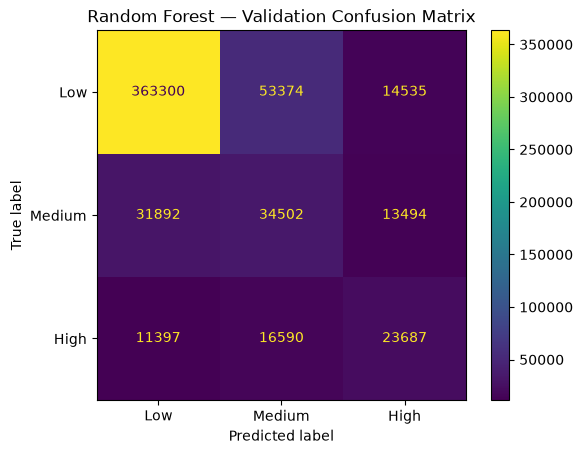

In [54]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_val,
    rf_val_predictions,
    labels=["Low", "Medium", "High"]
)

plt.title("Random Forest — Validation Confusion Matrix")
plt.show()

In [55]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Encode target labels
label_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

y_train_encoded = y_train.map(label_map)

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_encoded
)

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softmax",
                num_class=3,
                eval_metric="mlogloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_model.fit(
    X_train,
    y_train_encoded,
    classifier__sample_weight=sample_weights
)

xgb_val_predictions_encoded = xgb_model.predict(X_val)

inverse_label_map = {
    0: "Low",
    1: "Medium",
    2: "High"
}

xgb_val_predictions = pd.Series(
    xgb_val_predictions_encoded
).map(inverse_label_map)

print("XGBoost — Validation Performance")
print(
    classification_report(
        y_val,
        xgb_val_predictions,
        zero_division=0
    )
)

XGBoost — Validation Performance
              precision    recall  f1-score   support

        High       0.43      0.57      0.49     51674
         Low       0.93      0.73      0.82    431209
      Medium       0.28      0.54      0.37     79888

    accuracy                           0.69    562771
   macro avg       0.55      0.61      0.56    562771
weighted avg       0.79      0.69      0.73    562771



In [56]:
comparison = pd.DataFrame({
    "Model": [
        "Dummy Baseline",
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.77,
        0.77,
        0.61,
        0.75,
        0.69
    ],
    "Macro_F1": [
        0.29,
        0.29,
        0.40,
        0.57,
        0.61
    ],
    "High_Precision": [
        0.00,
        0.00,
        0.18,
        0.46,
        0.43
    ],
    "High_Recall": [
        0.00,
        0.00,
        0.52,
        0.46,
        0.57
    ],
    "High_F1": [
        0.00,
        0.00,
        0.27,
        0.46,
        0.49
    ]
})

comparison

,Model,Accuracy,Macro_F1,High_Precision,High_Recall,High_F1
0,Dummy Baseline,0.77,0.29,0.00,0.00,0.00
1,Logistic Regression,0.77,0.29,0.00,0.00,0.00
2,Balanced Logistic Regression,0.61,0.40,0.18,0.52,0.27
3,Random Forest,0.75,0.57,0.46,0.46,0.46
4,XGBoost,0.69,0.61,0.43,0.57,0.49


In [57]:
# Leakage-safe return capping:
# Fit cap thresholds using training-period returns only.

training_returns = daily_df.loc[
    daily_df["Arrival_Date"] <= "2024-12-31",
    "Price_Return"
].dropna()

lower_return = training_returns.quantile(0.01)
upper_return = training_returns.quantile(0.99)

daily_df["Return_Capped"] = daily_df["Price_Return"].clip(
    lower=lower_return,
    upper=upper_return
)

# Future 7-observation volatility using training-fitted cap values
daily_df["Future_Volatility_7D"] = (
    daily_df.groupby(["Commodity", "Market"])["Return_Capped"]
    .transform(
        lambda x: x.iloc[::-1]
        .rolling(window=7, min_periods=7)
        .std()
        .iloc[::-1]
    )
)

# Fit risk thresholds using training-period future volatility only
training_future_volatility = daily_df.loc[
    daily_df["Arrival_Date"] <= "2024-12-31",
    "Future_Volatility_7D"
].dropna()

p75 = training_future_volatility.quantile(0.75)
p90 = training_future_volatility.quantile(0.90)

daily_df["Future_Risk_Level"] = pd.cut(
    daily_df["Future_Volatility_7D"],
    bins=[-np.inf, p75, p90, np.inf],
    labels=["Low", "Medium", "High"]
)

print("Training-fitted return caps:")
print("Lower:", lower_return)
print("Upper:", upper_return)

print("\nTraining-fitted risk thresholds:")
print("Low / Medium:", p75)
print("Medium / High:", p90)

print("\nOverall target distribution:")
print(daily_df["Future_Risk_Level"].value_counts(dropna=False))

Training-fitted return caps:
Lower: -0.36170212765957444
Upper: 0.6000000000000001

Training-fitted risk thresholds:
Low / Medium: 0.13640741114400629
Medium / High: 0.2298498077415794

Overall target distribution:
Future_Risk_Level
Low       1792914
Medium     356908
High       234716
NaN         49062
Name: count, dtype: int64


In [58]:
train_df = daily_df[
    (daily_df["Arrival_Date"] >= "2022-01-01") &
    (daily_df["Arrival_Date"] <= "2024-12-31")
].copy()

val_df = daily_df[
    (daily_df["Arrival_Date"] >= "2025-01-01") &
    (daily_df["Arrival_Date"] <= "2025-12-31")
].copy()

test_df = daily_df[
    (daily_df["Arrival_Date"] >= "2026-01-01") &
    (daily_df["Arrival_Date"] <= "2026-04-20")
].copy()

required_columns = feature_columns + [target_column]

train_model_df = train_df[required_columns].dropna().copy()
val_model_df = val_df[required_columns].dropna().copy()
test_model_df = test_df[required_columns].dropna().copy()

print("Corrected model-ready shapes:")
print("Train:", train_model_df.shape)
print("Validation:", val_model_df.shape)
print("Test:", test_model_df.shape)

Corrected model-ready shapes:
Train: (1717831, 15)
Validation: (562771, 15)
Test: (23913, 15)


In [59]:
from sklearn.utils.class_weight import compute_sample_weight

y_train_encoded = y_train.map(label_map)

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_encoded
)

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softmax",
                num_class=3,
                eval_metric="mlogloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_model.fit(
    X_train,
    y_train_encoded,
    classifier__sample_weight=sample_weights
)

xgb_val_predictions_encoded = xgb_model.predict(X_val)

xgb_val_predictions = pd.Series(
    xgb_val_predictions_encoded
).map(inverse_label_map)

print("Corrected XGBoost — Validation Performance")
print(
    classification_report(
        y_val,
        xgb_val_predictions,
        zero_division=0
    )
)

Corrected XGBoost — Validation Performance
              precision    recall  f1-score   support

        High       0.43      0.57      0.49     51674
         Low       0.93      0.73      0.82    431209
      Medium       0.28      0.54      0.37     79888

    accuracy                           0.69    562771
   macro avg       0.55      0.61      0.56    562771
weighted avg       0.79      0.69      0.73    562771



In [60]:
# Final evaluation on the unseen 2026 test period

xgb_test_predictions_encoded = xgb_model.predict(X_test)

xgb_test_predictions = pd.Series(
    xgb_test_predictions_encoded
).map(inverse_label_map)

print("XGBoost — Final Test Performance")
print(
    classification_report(
        y_test,
        xgb_test_predictions,
        zero_division=0
    )
)

XGBoost — Final Test Performance
              precision    recall  f1-score   support

        High       0.42      0.64      0.51      3207
         Low       0.89      0.59      0.71     15813
      Medium       0.29      0.51      0.37      4893

    accuracy                           0.58     23913
   macro avg       0.54      0.58      0.53     23913
weighted avg       0.71      0.58      0.62     23913



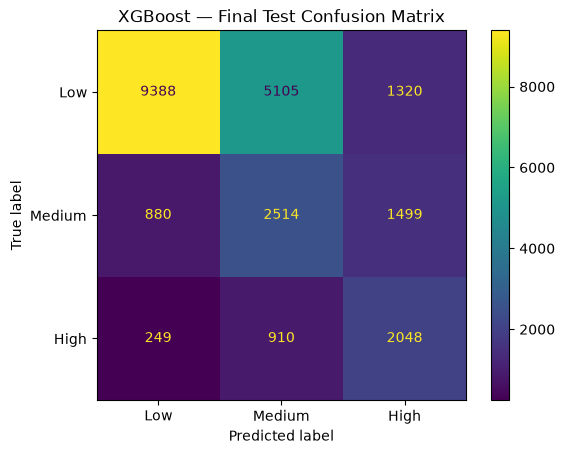

In [62]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_test_predictions,
    labels=["Low", "Medium", "High"]
)


plt.title("XGBoost — Final Test Confusion Matrix")
plt.show()